In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr 
import tqdm
from direvo_functions import *
import scripts.empirical_landscape_decay_curves as eld
import ruggedness_functions as rf
import pickle as pkl
import matplotlib.pyplot as plt

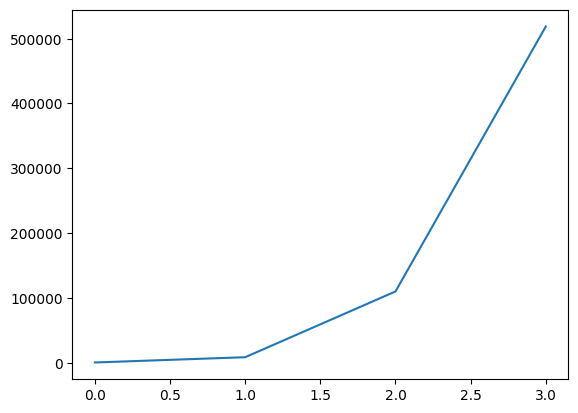

In [3]:
rng = jr.PRNGKey(42)
N = 4
A = 20
example_rmf = eld.build_rough_mount_fuji_landscape_function(rng, N, slope_scale=0.0, noise_scale=2.0)
shape_used = (A,)*N
array_landy = eld.get_array_from_function(example_rmf, shape = shape_used)
spectrum = rf.get_landscape_spectrum(array_landy, remove_constant= True)
plt.plot(spectrum)

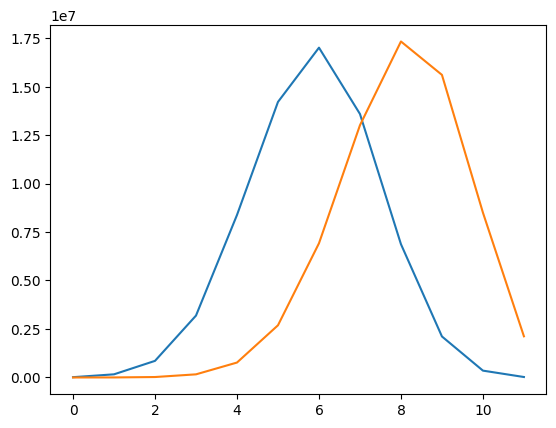

In [4]:
codon_landy = convert_landscape_function_to_codon(example_rmf)
codon_array = eld.get_array_from_function(codon_landy, shape = (4,)*(N*3))
example_other = eld.build_rough_mount_fuji_landscape_function(rng, N*3, slope_scale=0.0, noise_scale=2.0)
other_example_arry = eld.get_array_from_function(example_other, shape = (4,)*(N*3))
codon_spectrum = rf.get_landscape_spectrum(codon_array, remove_constant= True)
other_spectrum = rf.get_landscape_spectrum(other_example_arry, remove_constant= True)
plt.plot(codon_spectrum)
plt.plot(other_spectrum)

In [5]:
(spectrum* jnp.arange(1, 5)).sum()*(20/19) / spectrum.sum() /3

Array(1.3331158, dtype=float32)

In [6]:
(codon_spectrum * jnp.arange(1, 13)).sum()*4/3 / codon_spectrum.sum() /12

Array(0.7616982, dtype=float32)

In [7]:
3**3

27

In [8]:
64**4

16777216

In [9]:
convert_landscape_function_to_codon

<function direvo_functions.convert_landscape_function_to_codon(landscape_function)>

In [10]:
example_rmf( jnp.array([[0,]*9]) )

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 4: axis 0 of argument base_rng of type uint32[4,2];
  * one axis had size 9: axis 0 of argument data of type int32[9]